In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

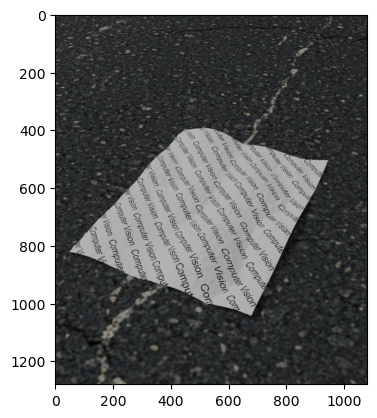

In [267]:
image = cv2.imread("synthetic_data/input (1).jpg")
# show color image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

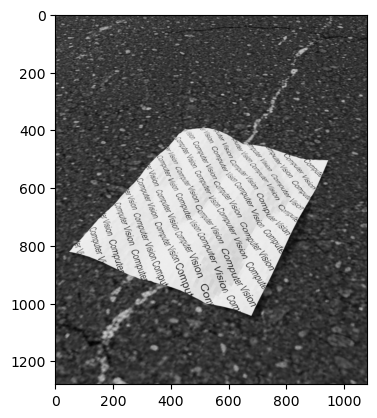

In [268]:
imGray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(imGray, cmap='gray')

In [269]:
img_scale = 0.25
small = cv2.resize(imGray, None, fx=img_scale, fy=img_scale)
small_color = cv2.resize(image, None, fx=img_scale, fy=img_scale)
blurred_small = cv2.bilateralFilter(small, 9, 75, 75)

In [ ]:
pixels = blurred_small.reshape(-1, 1).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(pixels, 3, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# keep only the brightest cluster
document_label = np.argmax(centers)
thresh = (labels.reshape(blurred_small.shape) == document_label).astype(np.uint8) * 255
plt.imshow(thresh, cmap='gray')

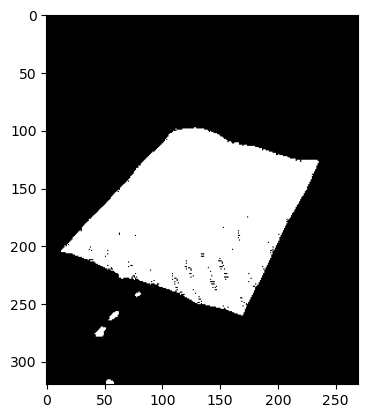

In [271]:
otsuVal, otsuThresh = cv2.threshold(blurred_small, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(otsuThresh, cmap='gray')

In [272]:
# TESTING percentile instead of otsu
# thresh_val = np.percentile(blurred_small, 78)
# _, thresh = cv2.threshold(blurred_small, thresh_val, 255, cv2.THRESH_BINARY)

In [273]:
pixels = blurred_small.copy().reshape(-1, 1).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(pixels, 2, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# document cluster is the brighter one
document_label = np.argmax(centers)
thresh = (labels.reshape(blurred_small.shape) == document_label).astype(np.uint8) * 255

In [274]:
kernel = np.ones((3,3), np.uint8)
# kernel = np.ones((5,5), np.uint8)
# cleaned = cv2.morphologyEx(otsuThresh, cv2.MORPH_OPEN, kernel)
cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel) 


# kernel_close = np.ones((7,7), np.uint8)
# kernel_open = np.ones((5,5), np.uint8)
# cleaned = cv2.morphologyEx(otsuThresh, cv2.MORPH_CLOSE, kernel_close)  # bridge gaps first
# cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel_open)        # then kill noise
contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
maxContour = max(contours, key=cv2.contourArea)

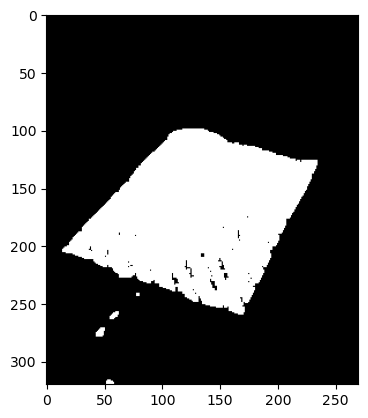

In [275]:
plt.imshow(cleaned, cmap='gray')

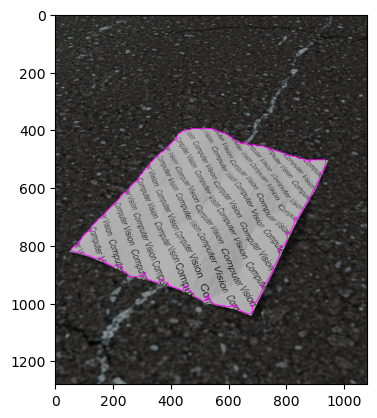

In [276]:
output = image.copy()
cv2.drawContours(output, [(maxContour / img_scale).astype(np.int32)], -1, (255, 0, 255), 2)
plt.imshow(output)

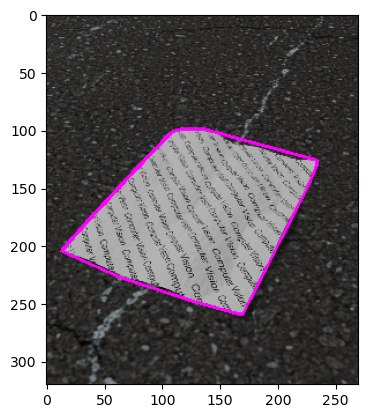

In [277]:
hull = cv2.convexHull(maxContour)
plt.imshow(cv2.drawContours(small_color.copy(), [hull], -1, (255, 0, 255), 2))

Found 4 corners with scale 0.02
[[[110 101]]

 [[234 126]]

 [[170 259]]

 [[ 14 205]]]


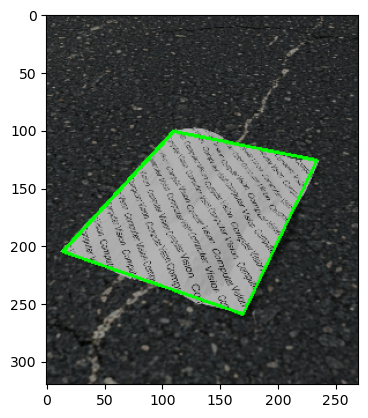

In [278]:
for scale in [0.02, 0.03, 0.04, 0.05, 0.06, 0.1]:
    epsilon = scale * cv2.arcLength(hull, True)
    approx = cv2.approxPolyDP(hull, epsilon, True)
    if len(approx) == 4:
        print(f"Found 4 corners with scale {scale}")
        break

output = small_color.copy()
cv2.drawContours(output, [approx], -1, (0, 255, 0), 2)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
print(approx)

In [247]:
# pts = hull.reshape(-1, 2)
# n = len(pts)
# angles = []
# for i in range(n):
#     p1 = pts[(i-1) % n]
#     p2 = pts[i]
#     p3 = pts[(i+1) % n]
#     v1 = p1 - p2
#     v2 = p3 - p2
#     cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-6)
#     angle = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))
#     angles.append((angle, i, pts[i]))

# # sort by closeness to 90
# angles.sort(key=lambda x: abs(x[0] - 90))

# # pick 4 that are well spread out
# min_dist = 20  # minimum distance between selected corners (in downscaled pixels)
# selected = []
# for angle, i, pt in angles:
#     if all(np.linalg.norm(pt - s[2]) > min_dist for s in selected):
#         selected.append((angle, i, pt))
#     if len(selected) == 4:
#         break

# corners = np.array([s[2] for s in selected])
# output = image.copy()
# for pt in corners:
#     pt_full = (pt / img_scale).astype(np.int32)
#     cv2.circle(output, tuple(pt_full), 10, (0, 255, 0), -1)
# plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

In [248]:
# contour_pts = maxContour.reshape(-1, 2)
contour_pts = approx.reshape(-1, 2)
sums = contour_pts.sum(axis=1)
diffs = np.diff(contour_pts, axis=1).flatten()

tl = contour_pts[np.argmin(sums)]
br = contour_pts[np.argmax(sums)]
tr = contour_pts[np.argmin(diffs)]
bl = contour_pts[np.argmax(diffs)]

ordered_approx = np.array([tl, tr, br, bl])
print(ordered_approx)

[[ 11 106]
 [112  44]
 [248 218]
 [104 285]]


In [249]:
approx_full = (ordered_approx / img_scale).astype(np.int32)

In [250]:
approx_full

array([[  44,  424],
       [ 448,  176],
       [ 992,  872],
       [ 416, 1140]], dtype=int32)

In [251]:
def order_points(points):
    pts = points.reshape(-1, 2)
    sums = pts.sum(axis=1)
    diffs = np.diff(pts, axis=1).flatten()
    top_left = pts[np.argmin(sums)]
    bottom_right = pts[np.argmax(sums)]
    top_right = pts[np.argmin(diffs)]
    bottom_left = pts[np.argmax(diffs)]
    ordered = np.array([top_left, top_right, bottom_right, bottom_left])
    return ordered

# Get corners from approxPolyDP (your current method)
print(approx_full.shape)
approx_corners = order_points(approx_full)

# Get corners from minAreaRect
rect = cv2.minAreaRect(maxContour)
box = cv2.boxPoints(rect)
box = np.int32(box)
rect_corners = order_points(box.reshape(4, 1, 2))

# For each corner, if it deviates significantly from minAreaRect, use minAreaRect corner
threshold = 20  # pixels
final_corners = []
for a, r in zip(approx_corners, rect_corners):
    dist = np.linalg.norm(a - r)
    if dist > threshold:
        final_corners.append(r)  # use rectangle corner
    else:
        final_corners.append(a)  # keep original
final_corners = np.array(final_corners)

(4, 2)


In [252]:
def is_corner_on_document(corner, image, threshold=75):
    x, y = corner[0]
    print(f'x: {x}, y: {y}')
    # sample a small patch around the corner
    patch = image[max(0,y-5):y+5, max(0,x-5):x+5]
    # print(patch)
    print(f'patch mean {patch.mean()}')
    return patch.mean() > threshold

In [253]:
approx

array([[[112,  44]],

       [[248, 218]],

       [[104, 285]],

       [[ 11, 106]]], dtype=int32)

In [254]:
for corner in approx:
    print(corner)

[[112  44]]
[[248 218]]
[[104 285]]
[[ 11 106]]


In [255]:
for corner in approx:
    print(f'corner: {corner}')
    print(is_corner_on_document(corner, small_color))

corner: [[112  44]]
x: 112, y: 44
patch mean 108.04
True
corner: [[248 218]]
x: 248, y: 218
patch mean 112.93666666666667
True
corner: [[104 285]]
x: 104, y: 285
patch mean 89.67
True
corner: [[ 11 106]]
x: 11, y: 106
patch mean 108.11666666666666
True


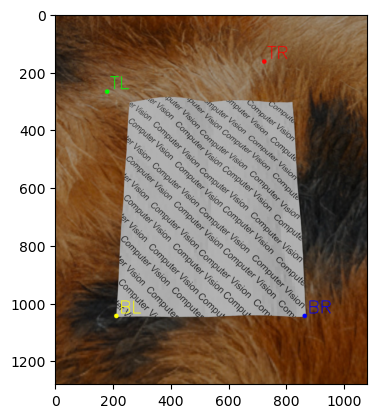

In [171]:
output = image.copy()
colors = [(0,255,0), (0,0,255), (255,0,0), (0,255,255)]  # TL, TR, BR, BL
labels = ['TL', 'TR', 'BR', 'BL']

for i, (x, y) in enumerate(approx_full):
    cv2.circle(output, (x, y), 8, colors[i], -1)           # draw colored circle
    cv2.putText(output, labels[i], (x+10, y-10),           # add label
                cv2.FONT_HERSHEY_SIMPLEX, 2.0, colors[i], 2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))